In [1]:
%load_ext autoreload
%autoreload 2
import copy, time, sys
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from astropy.io import fits as astropy_fits
from astropy import constants as const

from jax_cosmo import Cosmology
import jax_cosmo.background as bkgrd
from jax_cosmo.background import radial_comoving_distance

# ==========================================================
#                     PATHS
# ==========================================================

curr_path     = Path().resolve()                  # .../GODMAX/notebooks/tests
PROJECT_ROOT  = curr_path.parents[1]              # GODMAX repo root
DEVELOP       = curr_path.parents[1]              # tSZxEuclid repo root
abs_path_src  = PROJECT_ROOT / "src"
abs_path_data = Path("/home/vtinnane/Documents/Codes/develop/tSZxEuclid/Data")
abs_path_params = DEVELOP / "param_files"
FIGDIR        = curr_path / "plots"
FIGDIR.mkdir(exist_ok=True)

for p in (curr_path, abs_path_src):
    if str(p) not in sys.path:
        sys.path.append(str(p))

from get_Cls import get_Cl
# from loader import merge_params
import sys, os
abs_path_data = os.path.abspath(curr_path / "../../data/") 

import numpyro
numpyro.set_platform('cpu')
numpyro.enable_x64()
numpyro.set_host_device_count(jax.device_count())
jax.config.update('jax_enable_x64', True)
print('JAX devices:', jax.local_device_count())

import importlib.util
import get_Cls
import loader

print("\n--- GODMAX import paths ---")
print("get_Cls imported from:", get_Cls.__file__)
print("loader imported from :", loader.__file__)

print("\n--- importlib check ---")
print("get_Cls spec:", importlib.util.find_spec("get_Cls").origin)
print("loader spec :", importlib.util.find_spec("loader").origin)

print("\n--- sys.path entries relevant here ---")
for p in sys.path:
    if "GODMAX" in p or "tSZxEuclid" in p or str(abs_path_src) in p:
        print(p)



JAX devices: 1

--- GODMAX import paths ---
get_Cls imported from: /mnt/ceph/users/spandey/map_godmax/GODMAX/src/get_Cls.py
loader imported from : /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/loader/__init__.py

--- importlib check ---
get_Cls spec: /mnt/ceph/users/spandey/map_godmax/GODMAX/src/get_Cls.py
loader spec : /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/loader/__init__.py

--- sys.path entries relevant here ---
/mnt/ceph/users/spandey/map_godmax/GODMAX/notebooks/test
/mnt/ceph/users/spandey/map_godmax/GODMAX/src
/mnt/ceph/users/spandey/map_godmax/GODMAX/src/mcfitjax/cosmology_jax.py


## Load parameter files
Read the default YAML params and the project-specific `Pge` overrides, then merge (overrides
win) into the four config dicts GODMAX expects: `sim_params` (cosmo + gas + HOD),
`halo_params` (grid resolution), `analysis` (model flags + n(z)), `other_params` (IA / bias).

In [2]:
# =====================================================================
#                         LOAD PARAM FILES
# =====================================================================
import os, yaml

def read_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

params_default = read_yaml(abs_path_params / "params_default.yaml")
params_pge     = read_yaml(abs_path_params / "Pge" / "params.yaml")

# merge simple (overwrite default with pge)
sim_params_dict     = {**params_default["sim_params"], **params_pge["sim_params"]}
halo_params_dict    = {**params_default["halo_params"], **params_pge["halo_params"]}
analysis_dict       = {**params_default["analysis"],    **params_pge["analysis"]}
other_params_dict   = {**params_default["other_params"],**params_pge["other_params"]}


## Cosmology, ℓ and k grids
Build the `jax_cosmo` cosmology from the merged params. Then define the multipole grid
(log-spaced ℓ ∈ [10, 8000]) and the survey k-array — these are required inputs for the
theory C(ℓ) and P(k) calculations and are written back into the config dicts.

In [3]:
# =====================================================================
#                DEFINE COSMOLOGY
# =====================================================================

cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )

# =====================================================================
#                DEFINE ELL and K ARRAYs — REQUIRED FOR THEORY
# =====================================================================
lmin, lmax, dl_log_array = 10.0, 8000.0, 0.005325851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array    = l_array_all[1:] - l_array_all[:-1]        # delta ell in each bin
l_array_eff = (l_array_all[1:] + l_array_all[:-1]) / 2. # effective ell in each bin
halo_params_dict['ell_array']    = jnp.array(l_array_eff)
analysis_dict['l_array_survey']  = jnp.array(l_array_eff)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)

ks = np.geomspace(3e-3,10,10) 
analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

## Redshift distributions n(z)
Load and register the galaxy, lens, and source n(z):

- galaxy n(z) is converted to a **comoving** number density (÷ dV/dz/dΩ),
- 5 normalized lens bins and 5 source bins (same files here) are stacked into the
  `nz_*_info_dict` structures.

The plots show the per-bin n(z); the printed integrals confirm each normalized bin
integrates to ~1.

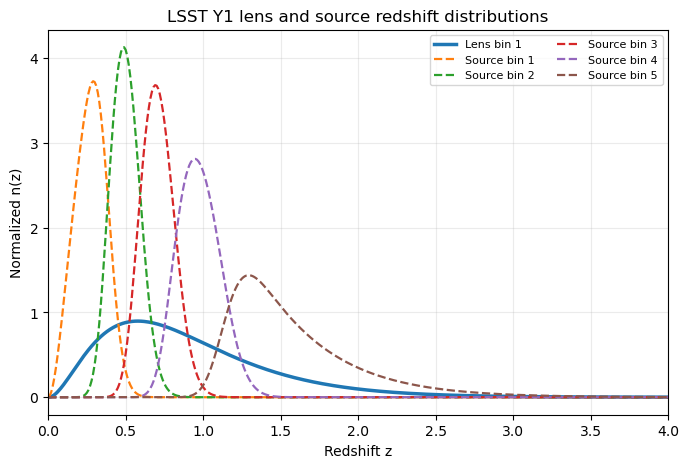

Loaded LSST N(z) from /mnt/ceph/users/spandey/map_godmax/GODMAX/data/forecast/lsst_simulate_Y1.fits
Lens bins: 1; source bins: 5
Integral lens bin 1: 1.0
Integral source bin 1: 1.0000000000000002
Integral source bin 2: 1.0
Integral source bin 3: 0.9999999999999999
Integral source bin 4: 1.0
Integral source bin 5: 1.0


In [4]:
# ==========================================================
#        LSST Y1 LENS AND SOURCE REDSHIFT DISTRIBUTIONS
# ==========================================================

if not hasattr(np, 'trapezoid'):
    np.trapezoid = np.trapz

def _fits_bin_columns(hdu):
    return [name for name in hdu.columns.names if name.startswith('BIN')]

def _normalized_nz_from_fits(hdu, col, z_array):
    nz = np.asarray(hdu.data[col], dtype=float)
    nz = np.nan_to_num(nz, nan=0.0, posinf=0.0, neginf=0.0)
    nz = np.clip(nz, 0.0, None)
    norm = np.trapezoid(nz, z_array)
    if norm <= 0.0:
        raise ValueError(f'{col} in {hdu.name} has non-positive integral')
    return nz / norm

def to_comoving_nz(z_array, nz_array, cosmo):
    z_array = np.asarray(z_array, dtype=float)
    nz_array = np.asarray(nz_array, dtype=float)
    scale_fac_a_array = jnp.asarray(1.0 / (1.0 + z_array))
    chi_array = np.asarray(radial_comoving_distance(cosmo, scale_fac_a_array))
    dchi_dz_array = np.asarray((const.c.value * 1e-3) / bkgrd.H(cosmo, scale_fac_a_array))
    dV_dzdOmega_array = chi_array**2 * dchi_dz_array
    return np.divide(
        nz_array,
        dV_dzdOmega_array,
        out=np.zeros_like(nz_array),
        where=dV_dzdOmega_array > 0.0,
    )

lsst_fits_path = Path(abs_path_data) / 'forecast' / 'lsst_simulate_Y1.fits'

# Set these to integers to use a subset of the available FITS bins.
requested_nbins_lens = None
requested_nbins_source = None

with astropy_fits.open(lsst_fits_path) as df:
    lens_hdu = df['nz_lens']
    source_hdu = df['nz_source']
    lens_cols = _fits_bin_columns(lens_hdu)
    source_cols = _fits_bin_columns(source_hdu)

    if requested_nbins_lens is not None:
        if requested_nbins_lens > len(lens_cols):
            raise ValueError(f'Requested {requested_nbins_lens} lens bins, but only {len(lens_cols)} are in {lsst_fits_path}')
        lens_cols = lens_cols[:requested_nbins_lens]

    if requested_nbins_source is not None:
        if requested_nbins_source > len(source_cols):
            raise ValueError(f'Requested {requested_nbins_source} source bins, but only {len(source_cols)} are in {lsst_fits_path}')
        source_cols = source_cols[:requested_nbins_source]

    nbins_lens = len(lens_cols)
    nbins_source = len(source_cols)
    z_lens = np.asarray(lens_hdu.data['Z_MID'], dtype=float)
    z_source = np.asarray(source_hdu.data['Z_MID'], dtype=float)
    nz_lens = {i: _normalized_nz_from_fits(lens_hdu, col, z_lens) for i, col in enumerate(lens_cols)}
    nz_source = {i: _normalized_nz_from_fits(source_hdu, col, z_source) for i, col in enumerate(source_cols)}

nz_lens_info_dict = {'z_array_lens': z_lens, 'nbins_lens': nbins_lens}
for i in range(nbins_lens):
    nz_lens_info_dict[f'nz{i}'] = nz_lens[i]
analysis_dict['nz_lens_info_dict'] = nz_lens_info_dict

nz_source_info_dict = {'z_array_source': z_source, 'nbins': nbins_source}
for i in range(nbins_source):
    nz_source_info_dict[f'nz{i}'] = nz_source[i]
analysis_dict['nz_source_info_dict'] = nz_source_info_dict

other_params_dict['Delta_z_bias_array'] = np.zeros(nbins_source)
other_params_dict['mult_shear_bias_array'] = np.zeros(nbins_source)

# get_Cl uses this comoving galaxy density for the HOD/galaxy profile calculation.
# The LSST FITS lens n(z) is normalized, so this is a nonzero shape proxy for this test notebook.
z_gal = z_lens
nz_gal = np.sum(np.vstack([nz_lens[i] for i in range(nbins_lens)]), axis=0)
nz_gal_comoving = to_comoving_nz(z_gal, nz_gal, cosmo_jax)
analysis_dict['nbar_gal_comoving_zarray'] = z_gal
analysis_dict['nbar_gal_comoving_val'] = nz_gal_comoving

# Keep the line-of-sight grid consistent with the redshift support in the datavector.
zmax_lsst = float(max(z_lens[-1], z_source[-1]))
analysis_dict['zmax_for_Cls'] = zmax_lsst
halo_params_dict['zmax'] = max(float(halo_params_dict.get('zmax', zmax_lsst)), zmax_lsst)

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(nbins_lens):
    ax.plot(z_lens, nz_lens[i], lw=2.5, label=f'Lens bin {i + 1}')
for i in range(nbins_source):
    ax.plot(z_source, nz_source[i], ls='--', lw=1.6, label=f'Source bin {i + 1}')
ax.set_xlabel('Redshift z')
ax.set_ylabel('Normalized n(z)')
ax.set_title('LSST Y1 lens and source redshift distributions')
ax.set_xlim(0.0, zmax_lsst)
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8)
plt.show()

print(f'Loaded LSST N(z) from {lsst_fits_path}')
print(f'Lens bins: {nbins_lens}; source bins: {nbins_source}')
for i in range(nbins_lens):
    print(f'Integral lens bin {i + 1}:', np.trapezoid(nz_lens[i], z_lens))
for i in range(nbins_source):
    print(f'Integral source bin {i + 1}:', np.trapezoid(nz_source[i], z_source))

## Lens-bin number densities
Split the total galaxy surface density into the 5 lens bins by their fractional n(z) share
at each z, integrate to get n̄ per bin (converted deg⁻² → arcmin⁻²), and store as
`nbar_lens_bins`. These set the shot-noise level for the galaxy probes.

In [5]:
from scipy.interpolate import interp1d

deg2_to_arcmin2 = 3600.0

nz_gal_interp = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
nz_gal_on_zlens = nz_gal_interp(z_lens)

# stack normalized bin PDFs
pz_bins = np.vstack([nz_lens[jb] for jb in range(nbins_lens)])   # shape (nbins, Nz)
pz_sum = np.sum(pz_bins, axis=0)

nbar_lens_bins = np.zeros(nbins_lens)

for jb in range(nbins_lens):
    frac_j = np.zeros_like(z_lens)
    valid = pz_sum > 0
    frac_j[valid] = pz_bins[jb, valid] / pz_sum[valid]

    nbar_deg2 = np.trapezoid(nz_gal_on_zlens * frac_j, z_lens)
    nbar_lens_bins[jb] = nbar_deg2 / deg2_to_arcmin2

analysis_dict['nbar_lens_bins'] = nbar_lens_bins

## Build the C(ℓ) object
Instantiate `get_Cl` with the four config dicts. This runs the full inheritance chain
(`base_class → Profiles → get_Pkz → get_Cl`): profiles, 3D power spectra, and angular power
spectra are all computed here and cached on the returned `cls` object.

In [6]:
# pk = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
cls = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)



## Matter power decomposition & baryonic ratios
Pull the cached P(k,z) matrices off `cls` and plot, at several redshifts:

- **Left:** the components — halofit, NFW total, DMB total, and the DMB 1-halo / 2-halo split.
  Colour family = component, shade = redshift (lighter → darker = low → high z).
- **Right:** the baryonic-modification ratios `P_DMB/P_NFW` and `P_tot/P_halofit`, which show
  the suppression relative to the no-bary baselines.

In [7]:
# Pdmbltot.shape, Pnfwtot.shape
# Pdmbltot/Pnfwtot

np.asarray(cls.Pmm_dmb_tot_mat)/np.asarray(cls.Pmm_nfw_tot_mat)



array([[0.99746697, 0.99774083, 0.9979957 , ..., 0.99994487, 0.9999644 ,
        0.99997821],
       [0.99749033, 0.99773666, 0.99798384, ..., 0.9999481 , 0.99996652,
        0.99997952],
       [0.99751367, 0.99773247, 0.9979721 , ..., 0.99995055, 0.99996812,
        0.99998051],
       ...,
       [0.19903336, 0.22994484, 0.25835549, ..., 0.54682799, 0.56614739,
        0.58750616],
       [0.17959781, 0.21156286, 0.24141539, ..., 0.56626853, 0.58977705,
        0.61533333],
       [0.16327354, 0.19603536, 0.22712371, ..., 0.61192617, 0.64120572,
        0.67183308]])

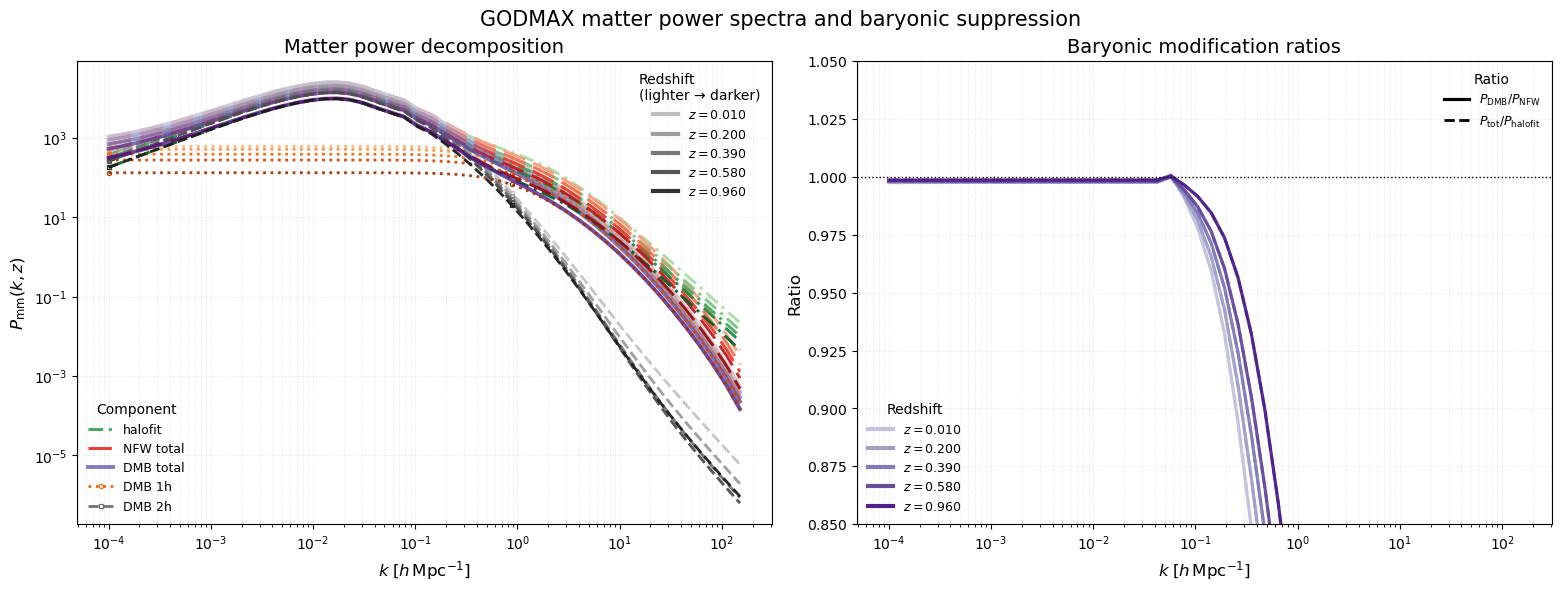

In [8]:
# ── Arrays ────────────────────────────────────────────────────────────────
k     = np.asarray(cls.kPk_array)
z_arr = np.asarray(cls.z_array)

Pnfwtot  = np.asarray(cls.Pmm_nfw_tot_mat)
Pdmbltot = np.asarray(cls.Pmm_dmb_tot_mat)
Pdmb_1h  = np.asarray(cls.Pmm_dmb_1h_kz_mat)
Pdmb_2h  = np.asarray(cls.Pmm_dmb_2h_kz_mat)
Phfit    = np.asarray(cls.phfit_kz_mat)
Psup     = np.asarray(cls.Pmm_sup_tot_mat)
Ptot     = np.asarray(cls.Pmm_tot_mat)

# Redshift indices to plot
z_indices = [0, 1, 2, 3, 5]
z_indices = [iz for iz in z_indices if iz < len(z_arr)]

# Ensure they are ordered in increasing z
z_indices = sorted(z_indices, key=lambda i: z_arr[i])

# ── Helpers ───────────────────────────────────────────────────────────────
def positive_for_log(y):
    """
    Mask non-positive values for log plotting.
    """
    y = np.asarray(y, dtype=float)
    return np.where(y > 0, y, np.nan)

def safe_ratio(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    return np.divide(
        num, den,
        out=np.full_like(num, np.nan, dtype=float),
        where=np.isfinite(den) & (den != 0)
    )

# ── Colour families for each component ────────────────────────────────────
# light -> dark corresponds to low z -> high z
shade_values = np.linspace(0.35, 0.90, len(z_indices))

component_cmaps = {
    "DMB total": plt.cm.Purples,
    "NFW total": plt.cm.Reds,
    "halofit":   plt.cm.Greens,
    "DMB 1h":    plt.cm.Oranges,
    "DMB 2h":    plt.cm.Greys,  
}

# Build per-component, per-redshift colours
component_colors = {
    comp: {
        iz: cmap(shade_values[j])
        for j, iz in enumerate(z_indices)
    }
    for comp, cmap in component_cmaps.items()
}

# ── Styles for decomposition plot ─────────────────────────────────────────
component_styles = {
    "halofit": {
        "ls": (0, (5, 2, 1, 2)),   # dash-dot
        "lw": 2.1,
        "marker": None,
    },
    "NFW total": {
        "ls": (0, (8, 3)),         # long dashed
        "lw": 2.1,
        "marker": None,
    },
    "DMB total": {
        "ls": "-",                 # solid
        "lw": 2.8,
        "marker": None,
    },
    "DMB 1h": {
        "ls": ":",
        "lw": 2.0,
        "marker": "o",
        "ms": 3.0,
        "markevery": 30,
        "markerfacecolor": "none",
        "markeredgewidth": 0.9,
    },
    "DMB 2h": {
        "ls": "--",
        "lw": 2.0,
        "marker": "s",
        "ms": 3.0,
        "markevery": 30,
        "markerfacecolor": "none",
        "markeredgewidth": 0.9,
    },
}

# ── Styles for ratio plot ─────────────────────────────────────────────────
# Here we keep a simpler scheme: redshift = purple shade, ratio = linestyle
ratio_styles = {
    r"$P_{\rm DMB}/P_{\rm NFW}$": {
        "ls": "-",
        "lw": 2.3,
    },
    r"$P_{\rm tot}/P_{\rm halofit}$": {
        "ls": "--",
        "lw": 2.0,
    },
}

ratio_cmap = plt.cm.Purples
ratio_colors = {
    iz: ratio_cmap(shade_values[j])
    for j, iz in enumerate(z_indices)
}

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(15.5, 5.8),
    constrained_layout=True
)

# =========================================================================
# Panel 1: Matter power decomposition
# =========================================================================
ax = axes[0]

for iz in z_indices:
    ax.loglog(
        k, positive_for_log(Phfit[:, iz]),
        color=component_colors["halofit"][iz],
        alpha=0.95,
        **component_styles["halofit"]
    )

    ax.loglog(
        k, positive_for_log(Pnfwtot[:, iz]),
        color=component_colors["NFW total"][iz],
        alpha=0.95,
        **component_styles["NFW total"]
    )

    ax.loglog(
        k, positive_for_log(Pdmbltot[:, iz]),
        color=component_colors["DMB total"][iz],
        alpha=0.8,
        **component_styles["DMB total"]
    )

    ax.loglog(
        k, positive_for_log(Pdmb_1h[:, iz]),
        color=component_colors["DMB 1h"][iz],
        alpha=0.95,
        **component_styles["DMB 1h"]
    )

    ax.loglog(
        k, positive_for_log(Pdmb_2h[:, iz]),
        color=component_colors["DMB 2h"][iz],
        alpha=0.95,
        **component_styles["DMB 2h"]
    )

ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$", fontsize=12)
ax.set_ylabel(r"$P_{\rm mm}(k,z)$", fontsize=12)
ax.set_title("Matter power decomposition", fontsize=14)
ax.grid(True, which="both", ls=":", lw=0.6, alpha=0.4)

# Legend 1: component meaning (colour family + line style)
component_handles = []
for comp, style in component_styles.items():
    # use the middle shade of each component family for the legend
    iz_mid = z_indices[len(z_indices)//2]
    component_handles.append(
        Line2D(
            [0], [0],
            color=component_colors[comp][iz_mid],
            ls=style["ls"],
            lw=style["lw"],
            marker=style.get("marker", None),
            markersize=style.get("ms", 0),
            markerfacecolor=style.get("markerfacecolor", "none"),
            markeredgecolor=component_colors[comp][iz_mid],
            markeredgewidth=style.get("markeredgewidth", 1.0),
            label=comp
        )
    )

leg1 = ax.legend(
    handles=component_handles,
    title="Component",
    fontsize=9,
    title_fontsize=10,
    loc="lower left",
    frameon=False
)
ax.add_artist(leg1)

# Legend 2: redshift shading guide
# use neutral grey shades to explain light -> dark mapping
grey_shades = np.linspace(0.75, 0.20, len(z_indices))
z_handles = [
    Line2D(
        [0], [0],
        color=str(grey_shades[j]),
        lw=3.0,
        label=rf"$z={z_arr[iz]:.3f}$"
    )
    for j, iz in enumerate(z_indices)
]

ax.legend(
    handles=z_handles,
    title="Redshift\n(lighter → darker)",
    fontsize=9,
    title_fontsize=10,
    loc="upper right",
    frameon=False
)

# =========================================================================
# Panel 2: Ratios
# =========================================================================
ax = axes[1]

for iz in z_indices:
    c = ratio_colors[iz]

    ratio_dmb_nfw  = safe_ratio(Pdmbltot[:, iz], Pnfwtot[:, iz])
    ratio_tot_hfit = safe_ratio(Ptot[:, iz], Phfit[:, iz])

    ax.semilogx(
        k, ratio_dmb_nfw,
        color=c,
        alpha=0.95,
        **ratio_styles[r"$P_{\rm DMB}/P_{\rm NFW}$"]
    )

    ax.semilogx(
        k, ratio_tot_hfit,
        color=c,
        alpha=0.80,
        **ratio_styles[r"$P_{\rm tot}/P_{\rm halofit}$"]
    )

ax.axhline(1.0, color="k", lw=1.0, ls=":")
ax.set_ylim(0.85, 1.05)

ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$", fontsize=12)
ax.set_ylabel("Ratio", fontsize=12)
ax.set_title("Baryonic modification ratios", fontsize=14)
ax.grid(True, which="both", ls=":", lw=0.6, alpha=0.4)

# Ratio legend
ratio_handles = [
    Line2D(
        [0], [0],
        color="k",
        ls=style["ls"],
        lw=style["lw"],
        label=name
    )
    for name, style in ratio_styles.items()
]

leg2 = ax.legend(
    handles=ratio_handles,
    title="Ratio",
    fontsize=9,
    title_fontsize=10,
    loc="upper right",
    frameon=False
)
ax.add_artist(leg2)

# Redshift legend for ratio panel
ratio_z_handles = [
    Line2D(
        [0], [0],
        color=ratio_colors[iz],
        lw=3.0,
        label=rf"$z={z_arr[iz]:.3f}$"
    )
    for iz in z_indices
]

ax.legend(
    handles=ratio_z_handles,
    title="Redshift",
    fontsize=9,
    title_fontsize=10,
    loc="lower left",
    frameon=False
)

# ── Overall title and save ────────────────────────────────────────────────
fig.suptitle(
    "GODMAX matter power spectra and baryonic suppression",
    fontsize=15
)

fig.savefig(
    FIGDIR / "Pmm_decomposition_component_hues.png",
    bbox_inches="tight",
    dpi=180
)

plt.show()

## Fourier-profile mass-conservation check
Diagnostic: every normalized Fourier profile must satisfy **u(k→0) = 1** (mass conservation).

- The printout compares the code's actual `u_DMB(k→0)` against the target 1.0, and reports the
  **window ratio** `M_grid[r_min,r_max] / M_tot[0.01,16·r200c]` — the root cause of an earlier
  overshoot (u_DMB → ~1.8) when the fixed FFT grid didn't match the per-halo normalization window.
- The 5-panel figure shows `u_DMB`, `u_NFW`, `u_CLM`, `u_ne`, and `u_y` vs k across halo masses;
  each should approach the dashed line at 1 on large scales.

u_DMB(k->0)  [code actual]   min=0.939  max=1.818   (target 1.000)
window ratio M_grid/Mtot     min=0.945  max=1.777
worst window: z=0.010  logM=11.50  ratio=1.777   16*r200c=1.79 Mpc  vs rmax=16.00 Mpc
the shapes:  (22, 24) (22, 24)


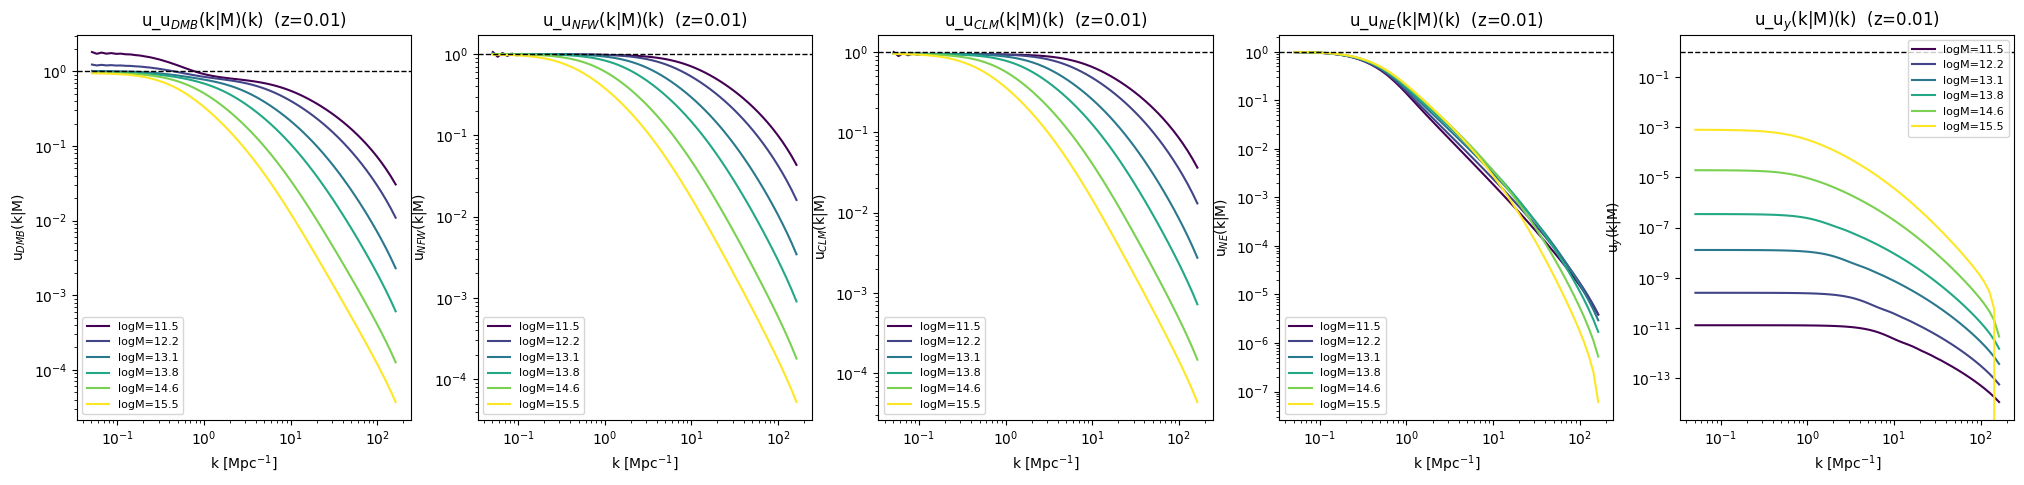

In [8]:
# ======================================================================
#   DIAGNOSTIC + FIX CHECK:  is the DMB Fourier profile mass-conserving?
#   u_DMB(k|M) = FFTLog(rho_dmb / norm).  Low-k limit MUST equal 1.
#
#   Panel A : the code's ACTUAL u_DMB(k)  (uk_dmb_tointp).
#             -> BEFORE fix it overshoots to ~1.8 at low-M/low-z.
#             -> AFTER fix (rho_dmb / Mdmb_grid in get_Pkzs) it sits on 1.
#   Panel B : INVESTIGATION of the window mismatch that caused it:
#             ratio = M_grid[rmin,rmax] / Mtot[0.01,16*r200c].
#             ratio>1  -> grid extends past 16*r200c, gas tail leaks IN.
#             ratio<1  -> grid truncates before 16*r200c, mass cut OFF.
#   (Panel B is computed from rho/Mtot directly, so it shows the underlying
#    window shift regardless of which normalisation the code currently uses.)
# ======================================================================

obj  = cls                                     # has Profiles+get_Pkz attrs
r    = np.array(obj.r_array)
z    = np.array(obj.z_array)
M    = np.array(obj.M_array); lgM = np.log10(M)
Mtot = np.array(obj.Mtot_mat)
r200 = np.array(obj.r200c_mat)

# Panel A: the code's actual Fourier profile on the mcfit k-grid
k_mc   = np.array(obj.k_mcfit)
uk_dmb = np.array(obj.uk_dmb_tointp)               # [nk_mcfit, nz, nM]
klo    = int(np.argmin(k_mc))
u0     = uk_dmb[klo, :, :]                         # ~ u_DMB(k->0)

# Panel B: window-shift investigation (grid mass vs Mtot window)
Mgrid_dmb = np.trapezoid(4*np.pi*r[:,None,None]**2*np.array(obj.rho_dmb_mat), x=r, axis=0)
ratio     = Mgrid_dmb / Mtot

print(f"u_DMB(k->0)  [code actual]   min={u0.min():.3f}  max={u0.max():.3f}   (target 1.000)")
print(f"window ratio M_grid/Mtot     min={ratio.min():.3f}  max={ratio.max():.3f}")
imax = np.unravel_index(np.argmax(ratio), ratio.shape)
print(f"worst window: z={z[imax[0]]:.3f}  logM={lgM[imax[1]]:.2f}  "
      f"ratio={ratio[imax]:.3f}   16*r200c={16*r200[imax]:.2f} Mpc  vs rmax={r[-1]:.2f} Mpc")

# fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# jz  = 0
# sel = np.linspace(0, len(M)-1, 6).astype(int)
# for c, jM in zip(plt.cm.viridis(np.linspace(0,1,len(sel))), sel):
#     ax[0].loglog(k_mc, uk_dmb[:,jz,jM], color=c, label=f"logM={lgM[jM]:.1f}")
# ax[0].axhline(1.0, ls="--", c="k", lw=1)
# ax[0].set(xlabel="k [Mpc$^{-1}$]", ylabel="u$_{DMB}$(k|M)",
#           title=f"u_DMB(k)  (z={z[jz]:.2f})")
# ax[0].legend(fontsize=8)

# for jz_ in range(len(z)):
#     ax[1].plot(lgM, ratio[jz_,:], "o-", ms=3, label=f"z={z[jz_]:.2f}")
# ax[1].axhline(1.0, ls="--", c="k", lw=1)
# ax[1].set(xlabel="log$_{10}$ M",
#           ylabel="$M_{grid}[r_{min},r_{max}] / M_{tot}[16 r_{200c}]$",
#           title="B: window mismatch (cause)")
# ax[1].legend(fontsize=7, ncol=2); ax[1].grid(alpha=.3)
# plt.tight_layout()
# plt.savefig(FIGDIR / "uDMB_k0_diagnostic.png", dpi=110)
# plt.show()

#plot the radial profiles of gg and yy
uk_nfw = np.array(obj.uk_nfw_tointp)               # [nk_mcfit, nz, nM]
klo    = int(np.argmin(k_mc))
unfw     = uk_nfw[klo, :, :]  

uk_clm = np.array(obj.uk_clm_tointp)               # [nk_mcfit, nz, nM]
klo    = int(np.argmin(k_mc))
uclm     = uk_clm[klo, :, :]  

uk_ne = np.array(obj.uk_ne_tointp)               # [nk_mcfit, nz, nM]
klo    = int(np.argmin(k_mc))
une     = uk_ne[klo, :, :]  

uk_y = np.array(obj.uk_y_tointp)               # [nk_mcfit, nz, nM]
klo    = int(np.argmin(k_mc))
u0     = uk_y[klo, :, :]  

print("the shapes: ", uclm.shape, une.shape)

fig, ax = plt.subplots(1, 5, figsize=(25, 5))
jz = 0
sel = np.linspace(0, len(M)-1, 6).astype(int)
for c, jM in zip(plt.cm.viridis(np.linspace(0,1,len(sel))), sel):
    ax[0].loglog(k_mc, uk_dmb[:,jz,jM], color=c, label=f"logM={lgM[jM]:.1f}")
    ax[1].loglog(k_mc, uk_nfw[:,jz,jM], color=c, label=f"logM={lgM[jM]:.1f}")
    ax[2].loglog(k_mc, uk_clm[:,jz,jM], color=c, label=f"logM={lgM[jM]:.1f}")
    ax[3].loglog(k_mc, uk_ne[:,jz,jM], color=c, label=f"logM={lgM[jM]:.1f}")
    ax[4].loglog(k_mc, uk_y[:,jz,jM], color=c, label=f"logM={lgM[jM]:.1f}")

labels = ["u$_{DMB}$(k|M)", "u$_{NFW}$(k|M)", "u$_{CLM}$(k|M)", "u$_{NE}$(k|M)", "u$_{y}$(k|M)"]
for i in range(5):
    ax[i].axhline(1.0, ls="--", c="k", lw=1)
    ax[i].set(xlabel="k [Mpc$^{-1}$]", ylabel=labels[i],
          title=f"u_{labels[i]}(k)  (z={z[jz]:.2f})")
    ax[i].legend(fontsize=8)

plt.savefig(FIGDIR / "u_profiles_k0.png", dpi=110)